In [ ]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import baltic as bt
import re
from collections import defaultdict
import pandas as pd

In [ ]:
json_folder = "jsons/"
clades = ['avian', 'swine', 'human', 'canine', 'equine']

records = []

for clade in clades:
    file_path = os.path.join(json_folder, f"{clade}.json")
    with open(file_path, "r") as file:
        data = json.load(file)

    for node_name, node_data in data["nodes"].items():

        reassorted_conf = node_data["reassorted_confidence"].get("True", np.nan)

        for segment, seg_conf in node_data.get("segments_confidence", {}).items():

            div_dict = node_data.get("divergence_confidence", {}).get(segment, {})
            if len(div_dict) == 0:
                continue

            divergence_val = float(list(div_dict.keys())[0])

            combined_support = reassorted_conf * seg_conf

            records.append({
                "clade": clade,
                "node": node_name,
                "segment": segment,
                "reassorted_conf": reassorted_conf,
                "segment_conf": seg_conf,
                "combined_support": combined_support,
                "divergence": divergence_val
            })

df = pd.DataFrame(records)

# filtering out any nodes never reassorted
df = df[df["reassorted_conf"] > 0].copy()

df



,clade,node,segment,reassorted_conf,segment_conf,combined_support,divergence
0,avian,NODE_591,NS,0.117,1.000,0.117,14.0
1,avian,NODE_9,NS,0.088,1.000,0.088,10.0
2,avian,A/mallard_duck/ALB/26/1976|1976-08-11,NA,1.000,1.000,1.000,548.0
3,avian,A/mallard_duck/ALB/26/1976|1976-08-11,NS,1.000,0.924,0.924,237.0
4,avian,NODE_8,NS,0.076,1.000,0.076,237.0
...,...,...,...,...,...,...,...
4654,equine,A/equine/Perthshire/3/09|2009-12-01,PB1,1.000,1.000,1.000,60.0
4655,equine,A/equine/Perthshire/3/09|2009-12-01,NA,1.000,1.000,1.000,37.0
4656,equine,NODE_104,NA,1.000,1.000,1.000,47.0
4657,equine,A/equine/Oregon/78356/2012|2012-02-01,NS,1.000,1.000,1.000,9.0


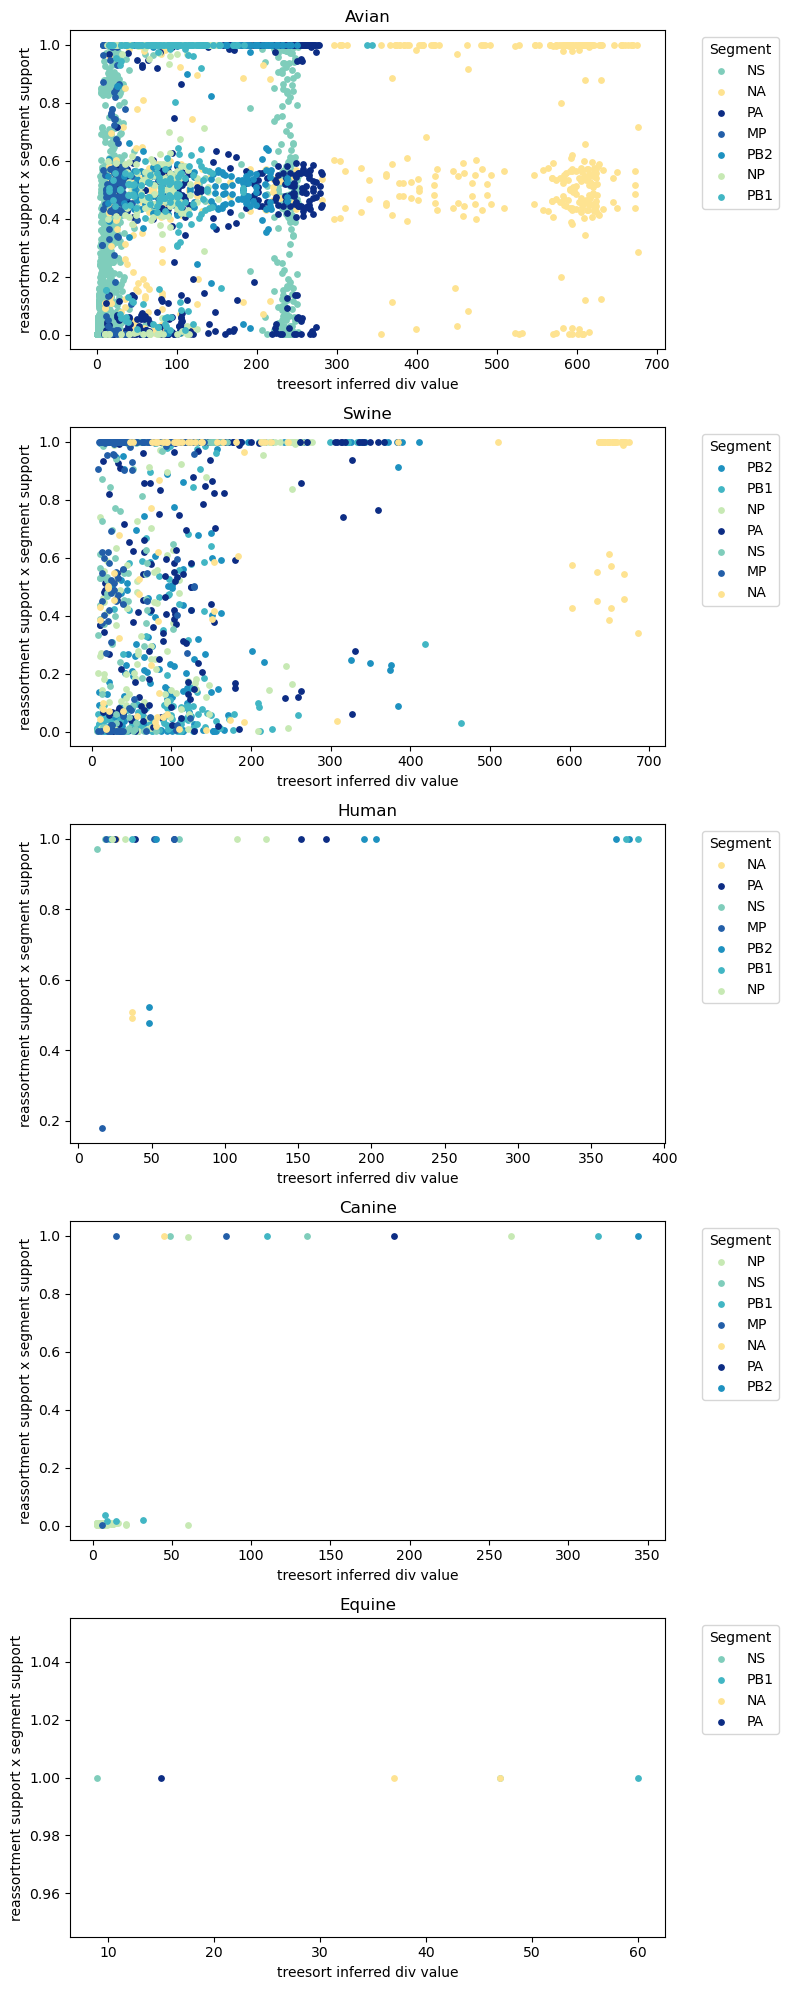

In [30]:
genes = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']
colors = ['#fee391', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']
segment_colors = dict(zip(genes, colors))

hosts = df['clade'].unique()
n_hosts = len(hosts)

fig, axes = plt.subplots(n_hosts, 1, figsize=(8, 4 * n_hosts))

if n_hosts == 1:
    axes = [axes]

for ax, host in zip(axes, hosts):
    sub = df[df['clade'] == host]

    for segment in sub['segment'].unique():
        seg_df = sub[sub['segment'] == segment]
        ax.scatter(
            seg_df['divergence'],
            seg_df['combined_support'],
            s=15,
            color=segment_colors.get(segment, "gray"),
            label=segment
        )

    ax.set_title(f"{host.capitalize()}")
    ax.set_xlabel("treesort inferred div value")      
    ax.set_ylabel("reassortment support x segment support")
    ax.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


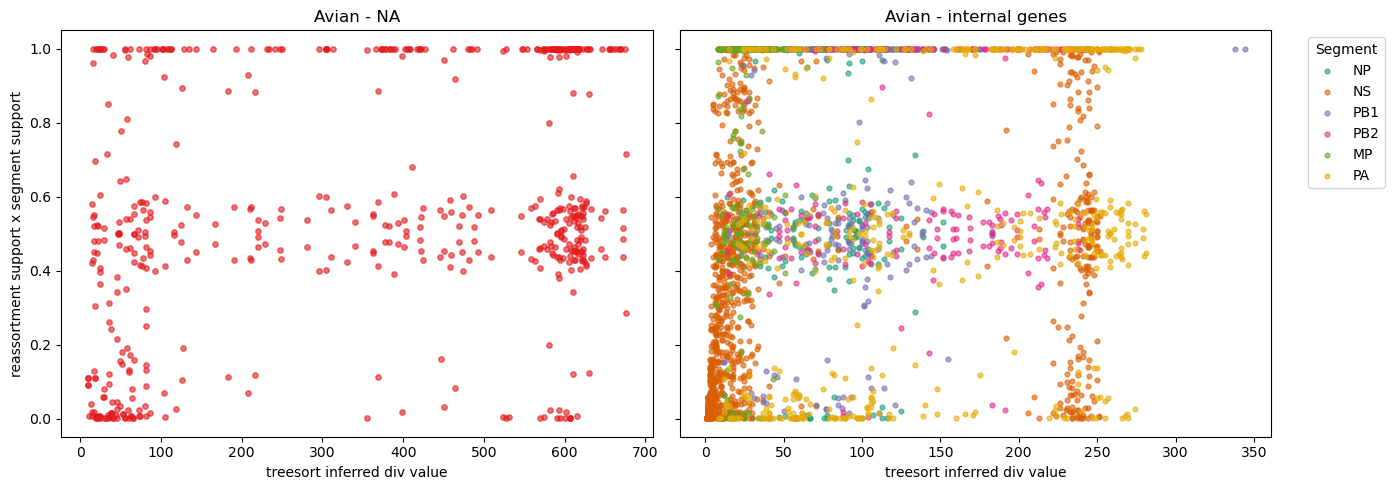

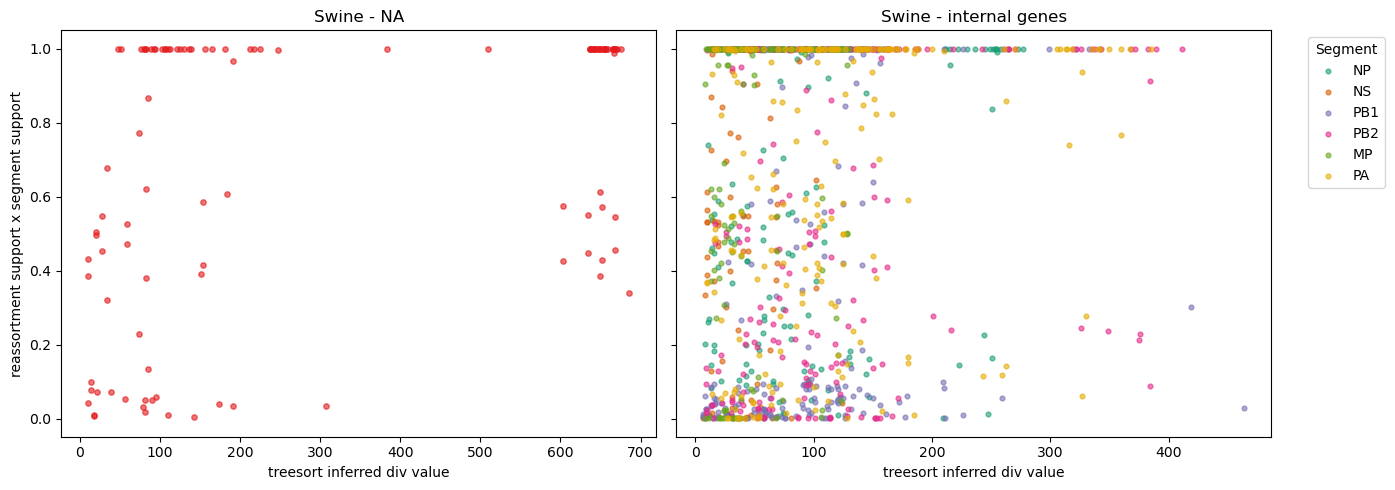

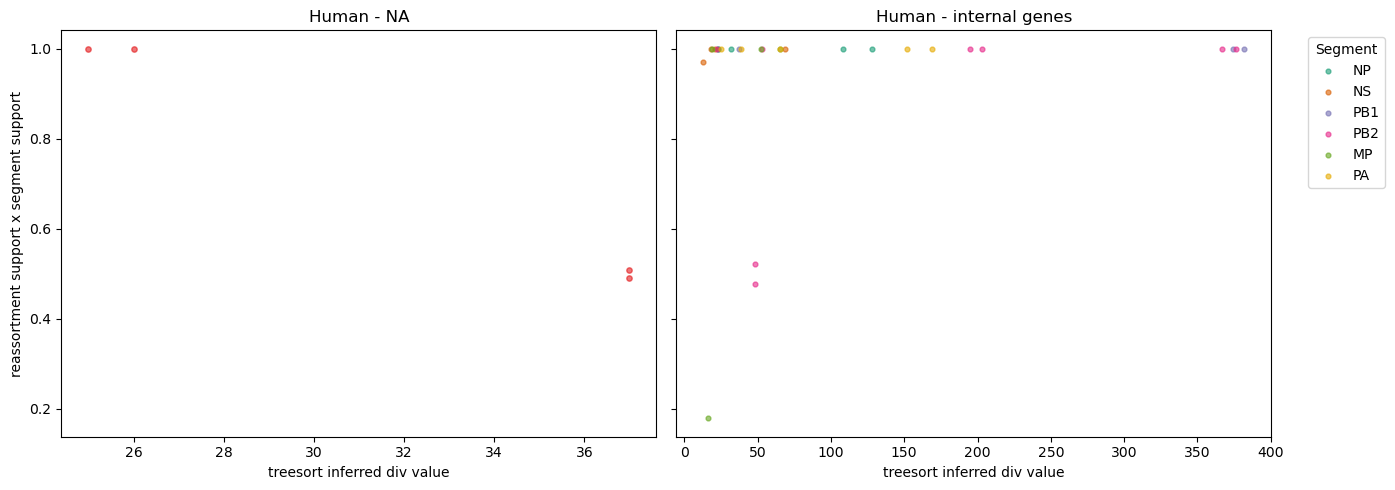

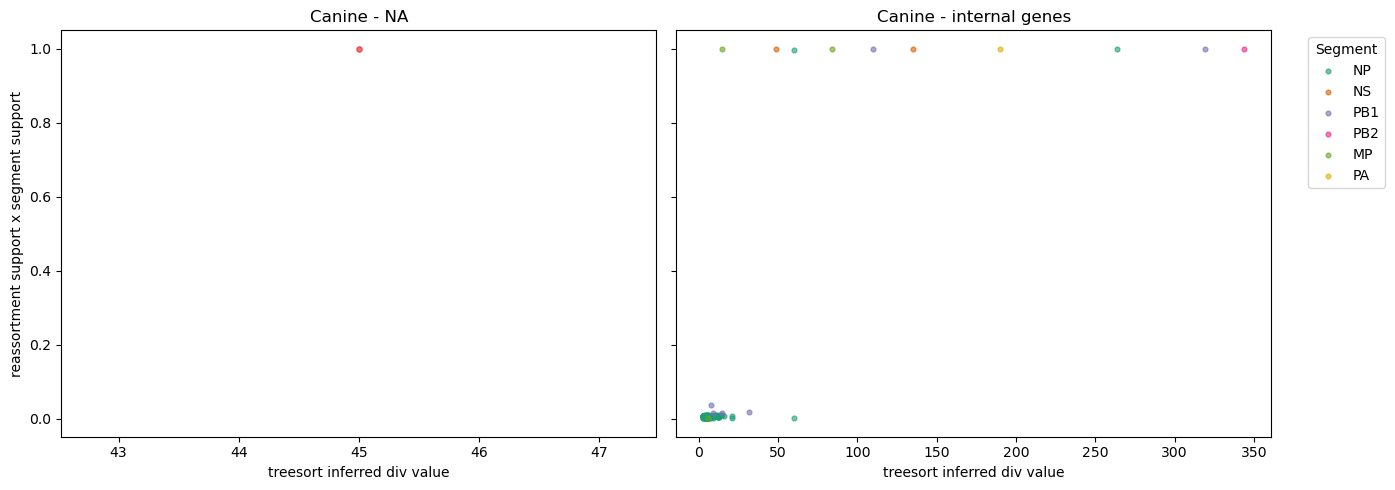

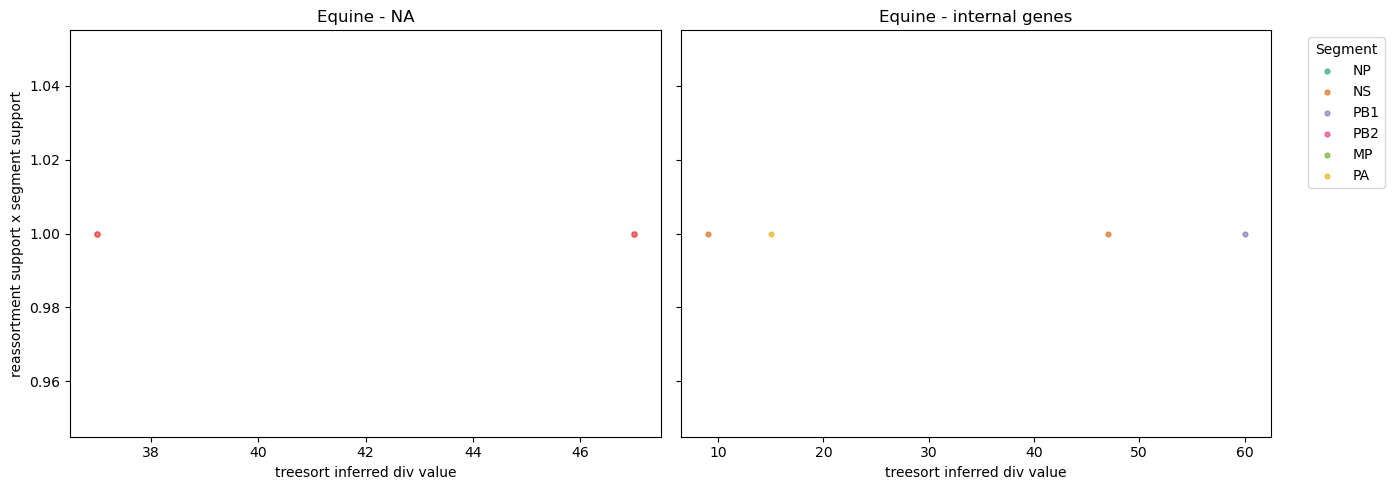

In [ ]:
# separating out NA since it has a much wider divergence range

hosts = df['clade'].unique()
internal_genes = ['NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

internal_colors = {
    'NP': '#1b9e77',   # green
    'NS': '#d95f02',   # orange
    'PB1': '#7570b3',  # purple
    'PB2': '#e7298a',  # pink
    'MP': '#66a61e',   # lime green
    'PA': '#e6ab02'    # gold
}

for host in hosts:
    sub = df[df['clade'] == host]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    na_df = sub[sub['segment'] == 'NA']
    axes[0].scatter(
        na_df['divergence'],
        na_df['combined_support'],
        s=15,
        alpha=0.6,
        color='#e41a1c'  # red for NA
    )
    axes[0].set_title(f"{host.capitalize()} - NA")
    axes[0].set_xlabel("treesort inferred div value")
    axes[0].set_ylabel("reassortment support x segment support")

    int_df = sub[sub['segment'].isin(internal_genes)]
    for segment in internal_genes:
        seg_df = int_df[int_df['segment'] == segment]
        axes[1].scatter(
            seg_df['divergence'],
            seg_df['combined_support'],
            s=12,
            alpha=0.6,
            color=internal_colors.get(segment, "gray"),
            label=segment
        )
    axes[1].set_title(f"{host.capitalize()} - internal genes")
    axes[1].set_xlabel("treesort inferred div value")
    axes[1].legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()
